In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
orders = pd.read_csv(
    "../Data/cleaned/orders_featured.csv"
)

order_items = pd.read_csv(
    "../Data/cleaned/order_items_featured.csv"
)

reviews = pd.read_csv(
    "../Data/cleaned/reviews_featured.csv"
)

payments = pd.read_csv(
    "../Data/cleaned/payments_clean.csv"
)

products = pd.read_csv(
    "../Data/cleaned/products_clean.csv"
)

customers = pd.read_csv(
    "../Data/cleaned/customers_clean.csv"
)

print("Datasets loaded successfully!")

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)

orders[
    [
        "purchase_year",
        "purchase_month",
        "delivery_days",
        "delay_days",
        "is_late",
        "total_order_value",
        "total_items"
    ]
].head()

Datasets loaded successfully!
Orders: (99441, 23)
Order Items: (112650, 8)
Reviews: (99224, 8)
Payments: (103886, 5)
Products: (32951, 9)
Customers: (99441, 5)


,purchase_year,purchase_month,delivery_days,delay_days,is_late,total_order_value,total_items
0,2017,10,8.44,-7.11,False,38.71,1.0
1,2018,7,13.78,-5.36,False,141.46,1.0
2,2018,8,9.39,-17.25,False,179.12,1.0
3,2017,11,13.21,-12.98,False,72.20,1.0
4,2018,2,2.87,-9.24,False,28.62,1.0


## 1. Order Status Analysis

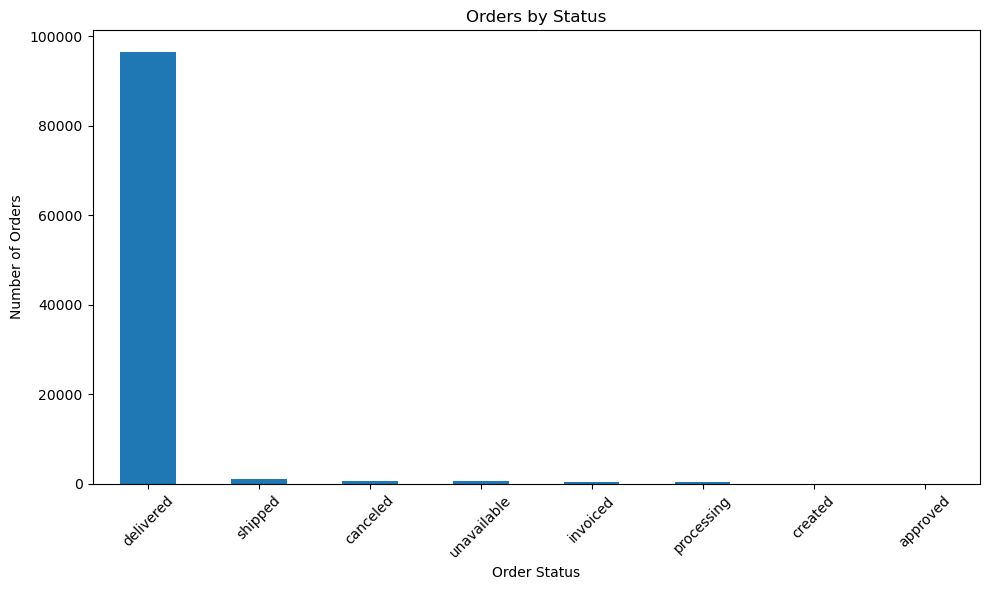

In [7]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

plt.figure(figsize=(10, 6))

order_status_counts.plot(kind="bar")

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

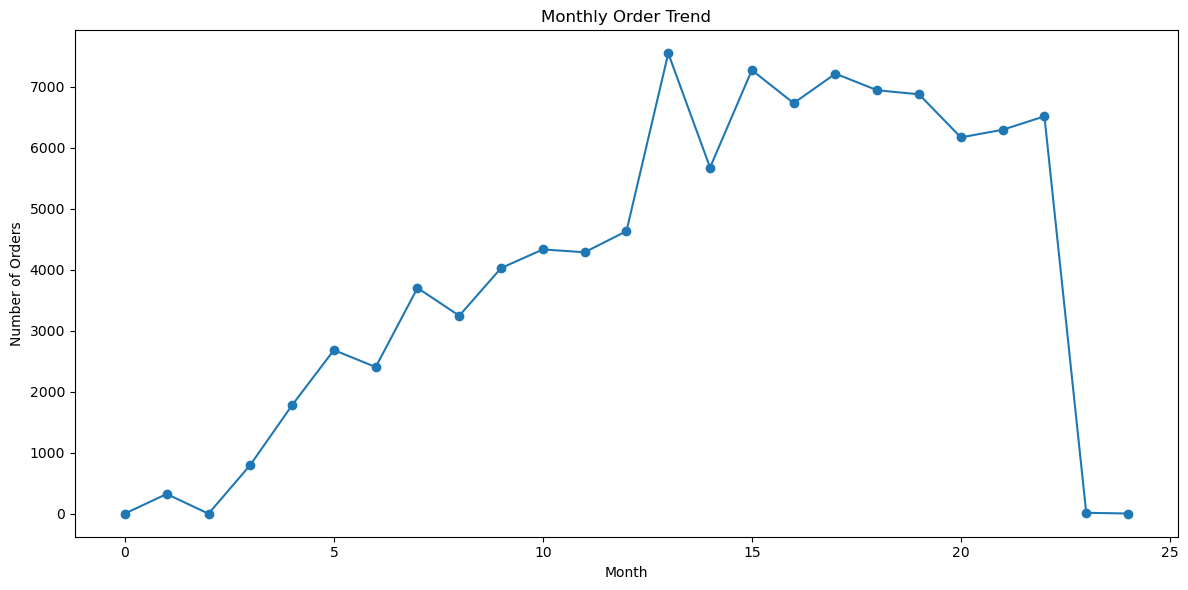

In [10]:
monthly_orders = (
    orders
    .groupby(
        ["purchase_year", "purchase_month"]
    )
    .size()
    .reset_index(name="total_orders")
)

monthly_orders.head()

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(monthly_orders)),
    monthly_orders["total_orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

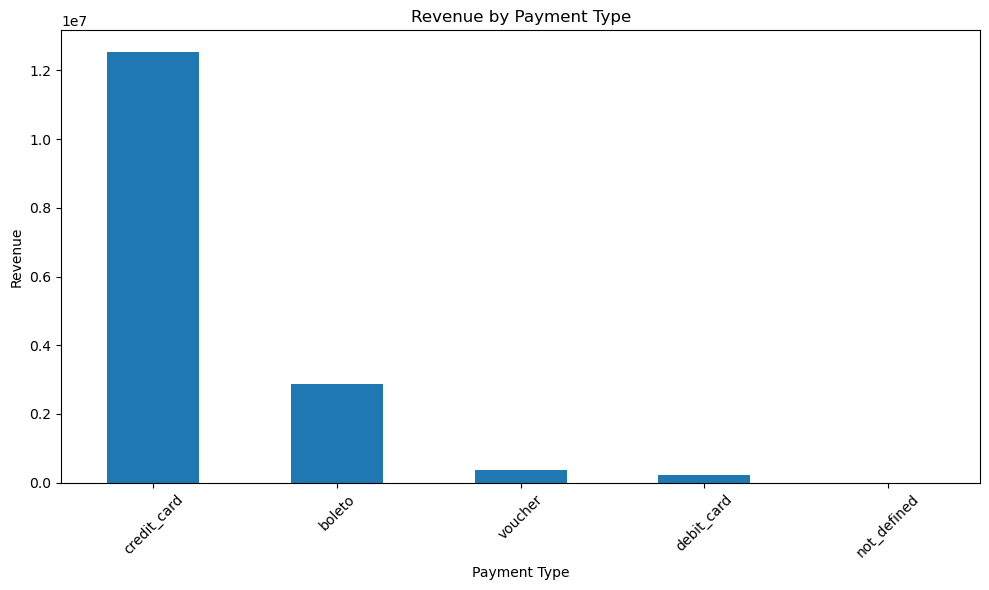

In [12]:
monthly_revenue = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

monthly_revenue

plt.figure(figsize=(10, 6))

monthly_revenue.plot(kind="bar")

plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer Analysis

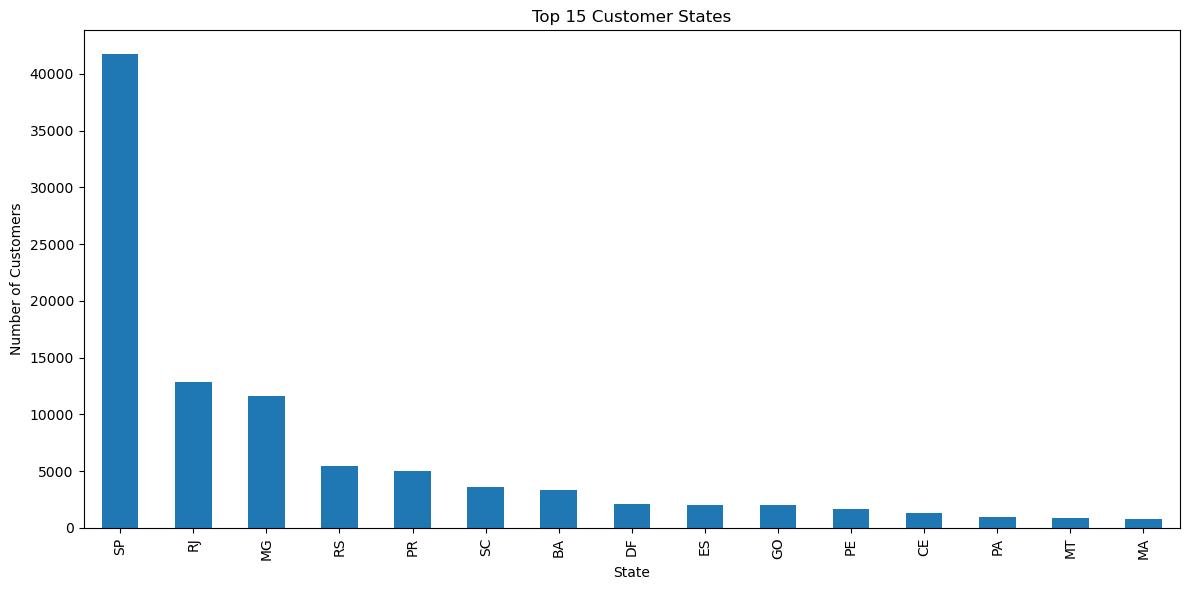

In [14]:
customers_by_state = (
    customers["customer_state"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

customers_by_state.plot(kind="bar")

plt.title("Top 15 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

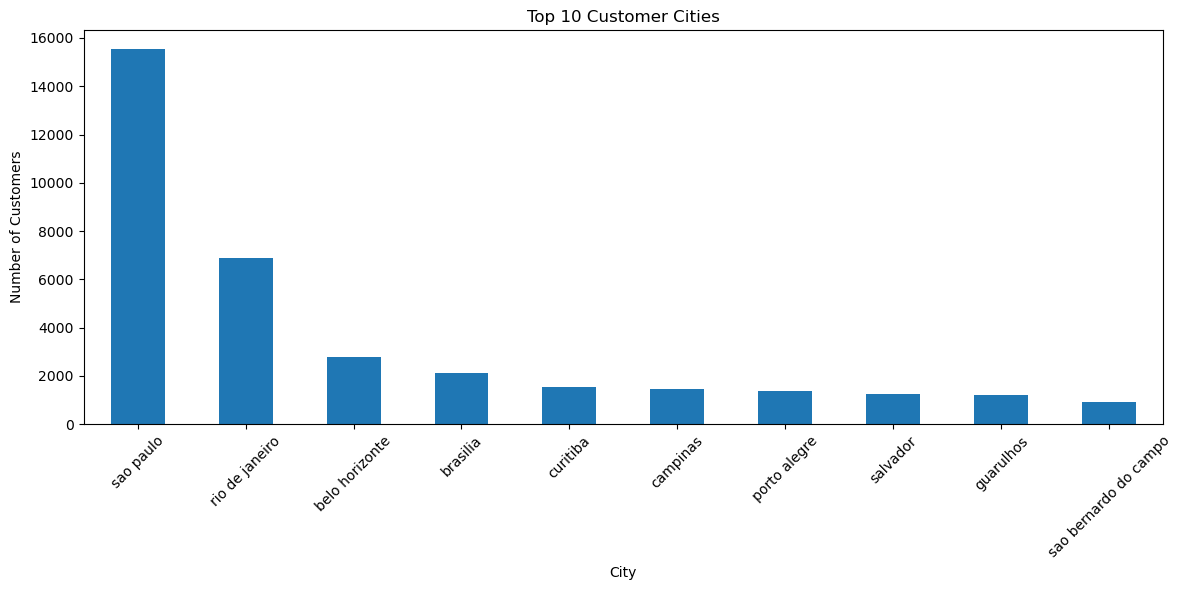

In [16]:
top_cities = (
    customers["customer_city"]
    .value_counts()
    .head(10)
)
plt.figure(figsize=(12, 6))

top_cities.plot(kind="bar")

plt.title("Top 10 Customer Cities")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product Analysis

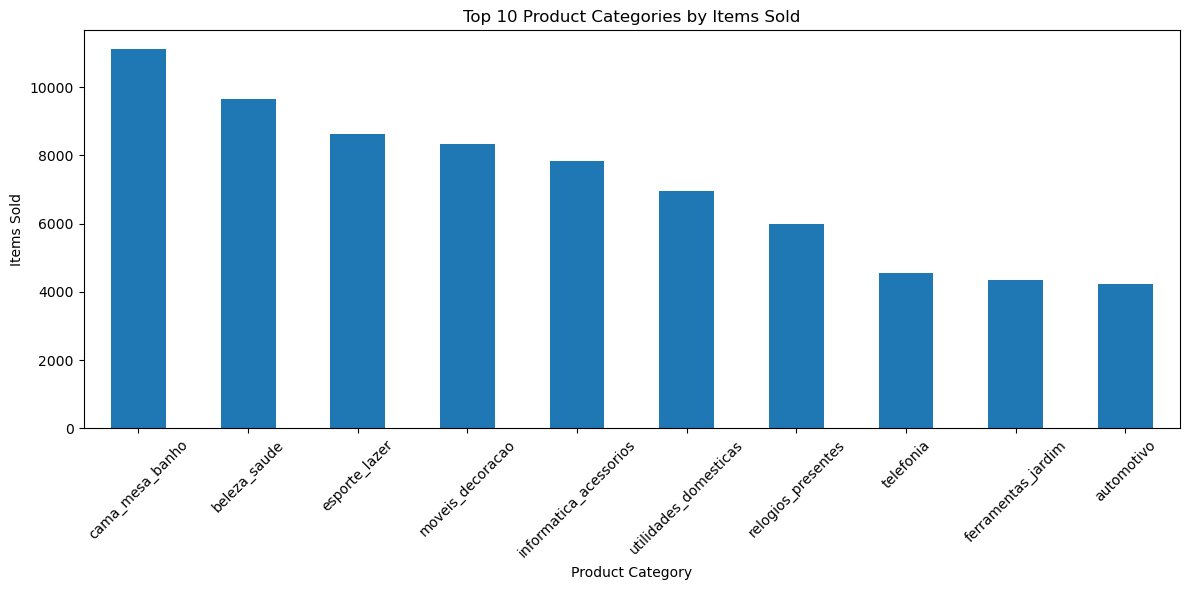

In [20]:
product_sales = order_items.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

top_categories = (
    product_sales["product_category_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Product Category")
plt.ylabel("Items Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

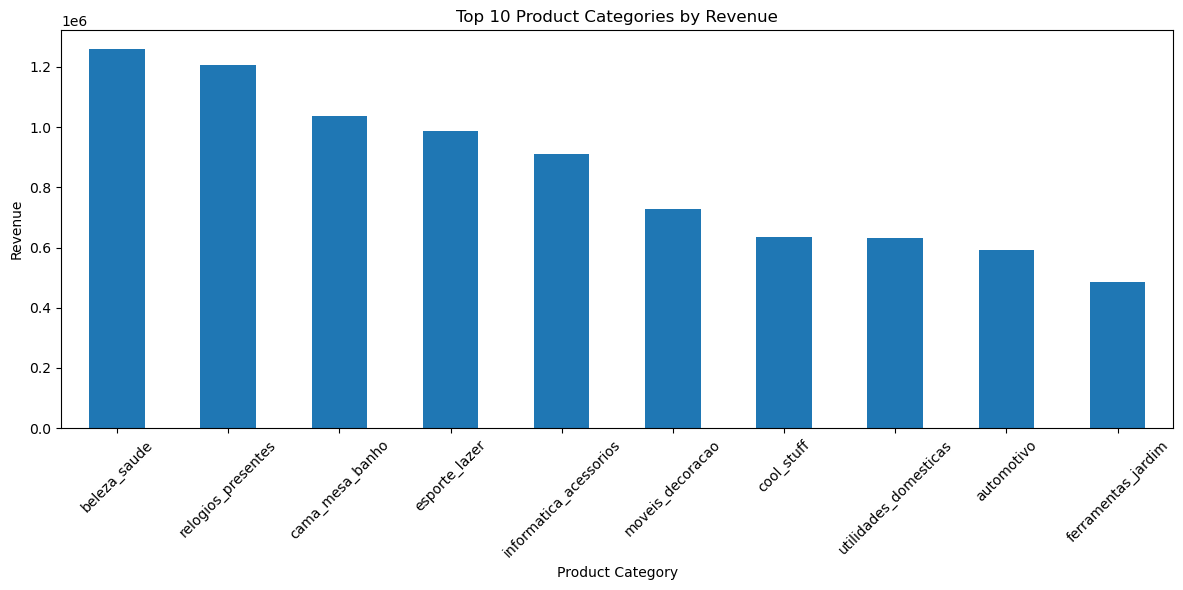

In [22]:
category_revenue = (
    product_sales
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

category_revenue.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delivery Analysis

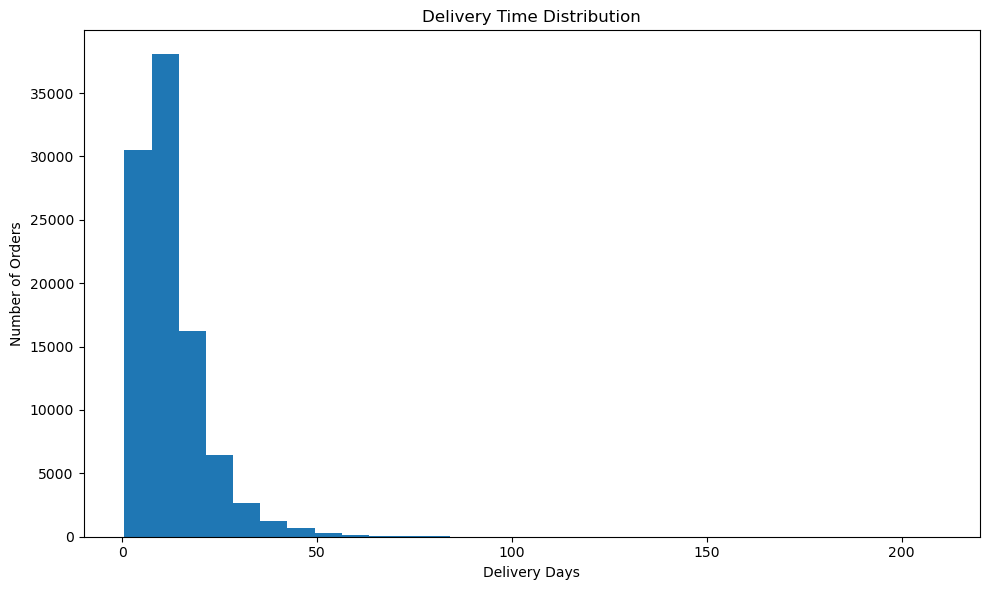

In [24]:
delivery_data = orders[
    orders["delivery_days"].notna()
]
plt.figure(figsize=(10, 6))

plt.hist(
    delivery_data["delivery_days"],
    bins=30
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

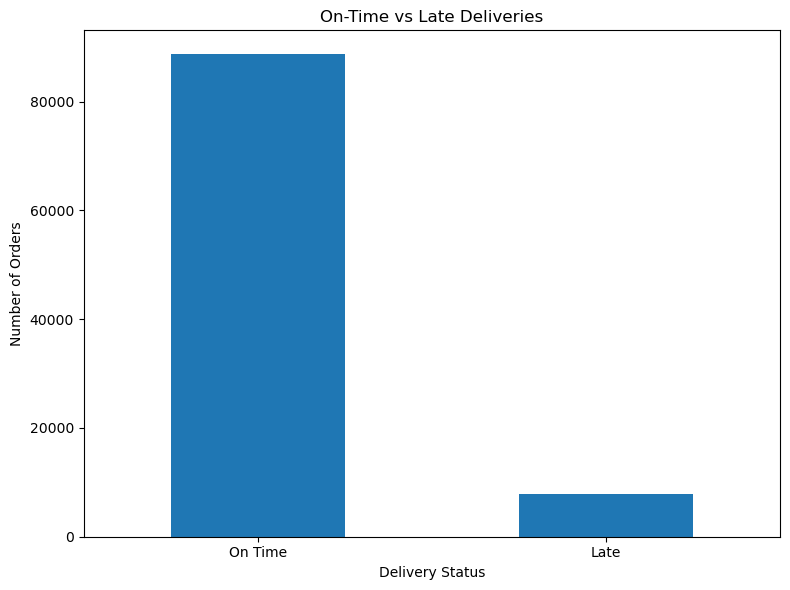

In [27]:
late_counts = (
    orders["is_late"]
    .value_counts(dropna=True)
)

late_counts.index = late_counts.index.map({
    True: "Late",
    False: "On Time"
})

plt.figure(figsize=(8, 6))

late_counts.plot(kind="bar")

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

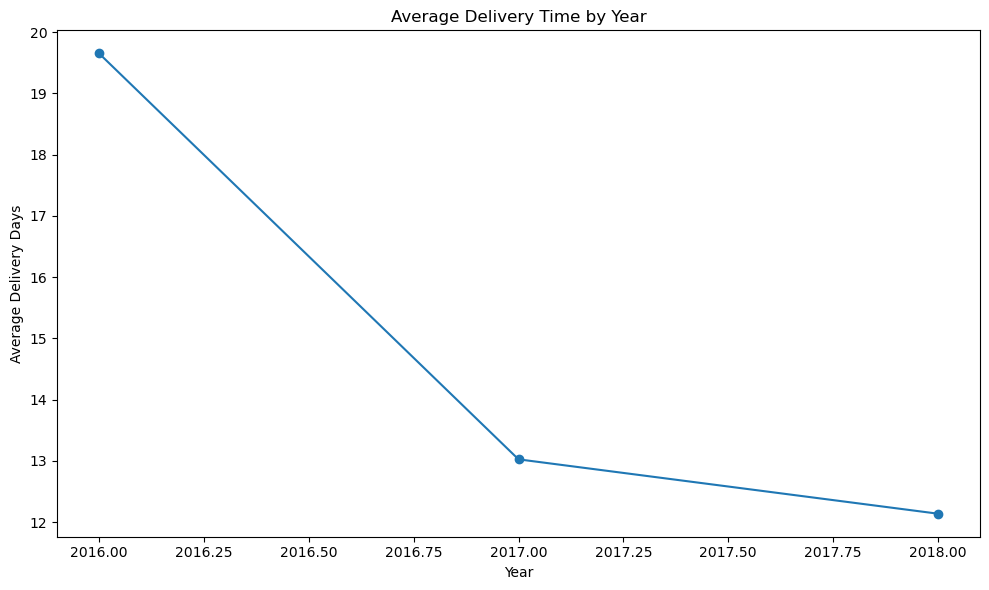

In [29]:
average_delivery_year = (
    orders
    .groupby("purchase_year")["delivery_days"]
    .mean()
)

plt.figure(figsize=(10, 6))

average_delivery_year.plot(kind="line", marker="o")

plt.title("Average Delivery Time by Year")
plt.xlabel("Year")
plt.ylabel("Average Delivery Days")

plt.tight_layout()
plt.show()

Customer Experience

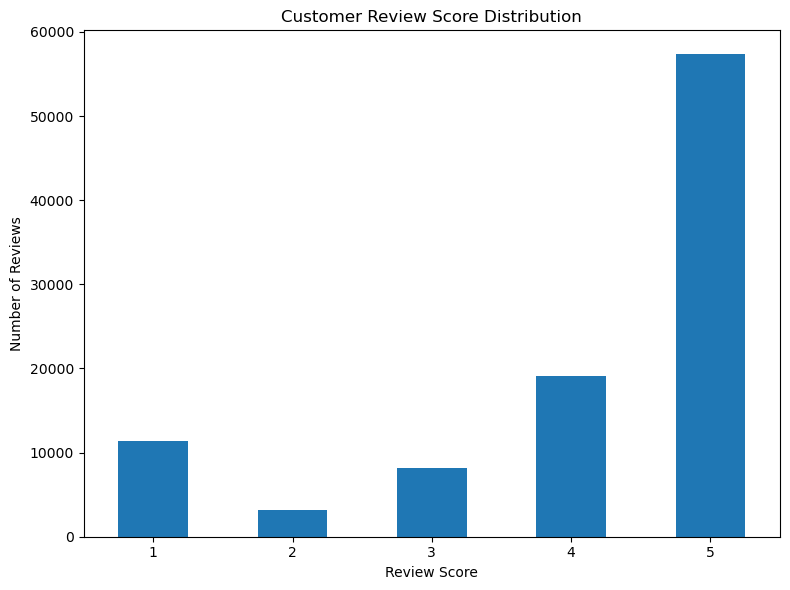

In [31]:
review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 6))

review_counts.plot(kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

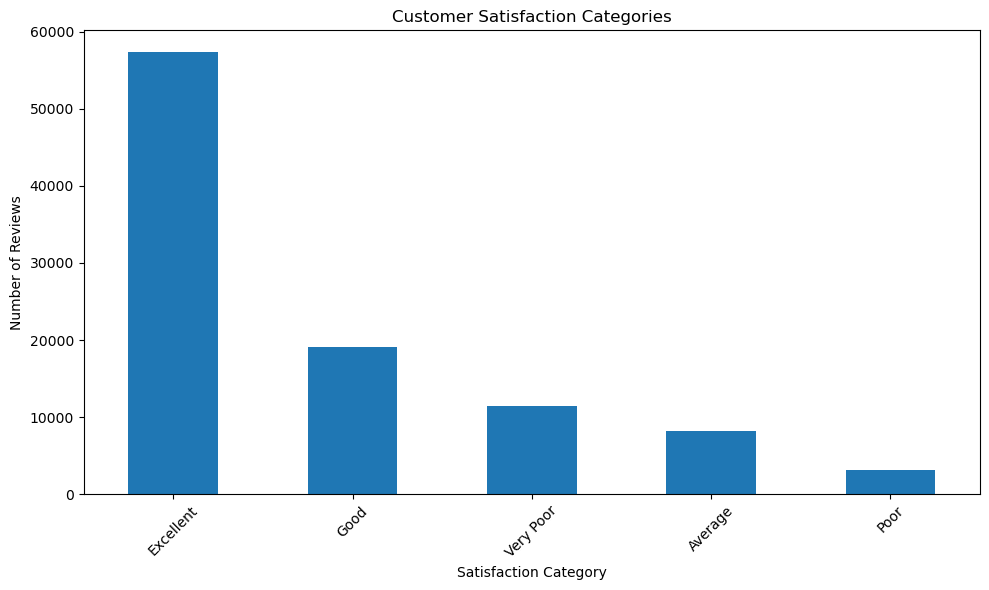

In [33]:
satisfaction_counts = (
    reviews["satisfaction_category"]
    .value_counts()
)
plt.figure(figsize=(10, 6))

satisfaction_counts.plot(kind="bar")

plt.title("Customer Satisfaction Categories")
plt.xlabel("Satisfaction Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Payment Analysis

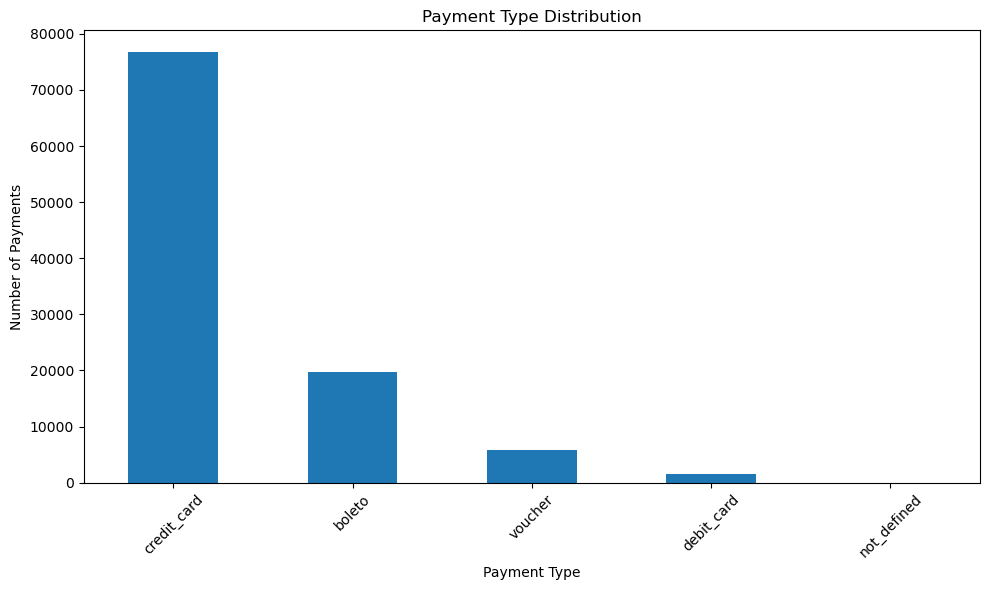

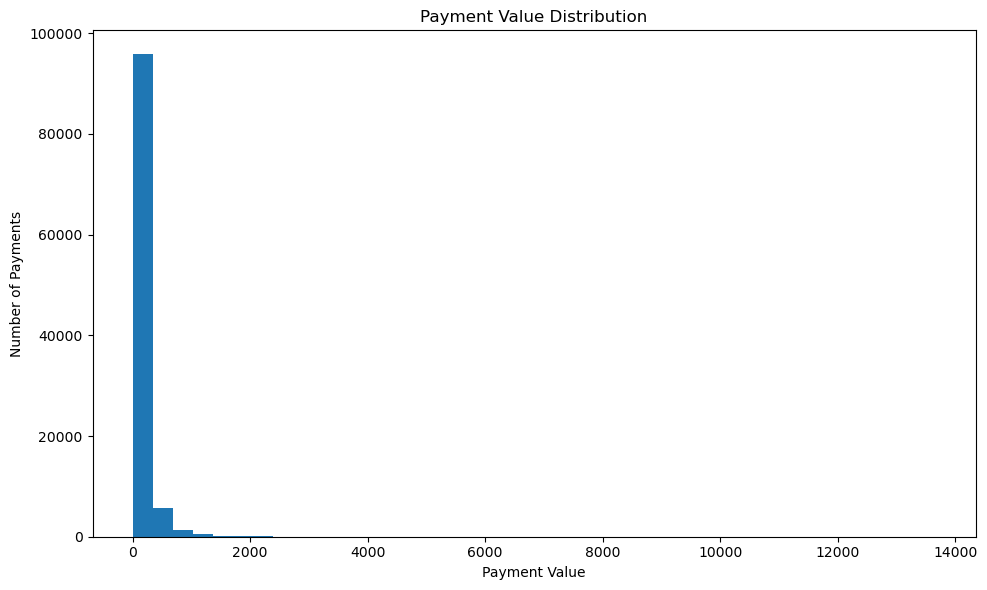

In [36]:
payment_counts = (
    payments["payment_type"]
    .value_counts()
)
plt.figure(figsize=(10, 6))

payment_counts.plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.hist(
    payments["payment_value"],
    bins=40
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Number of Payments")

plt.tight_layout()
plt.show()

# EDA Summary

The exploratory data analysis was performed to understand:

1. Order status distribution
2. Monthly order trends
3. Revenue by payment type
4. Customer distribution by state and city
5. Top-selling product categories
6. Revenue by product category
7. Delivery time distribution
8. On-time and late deliveries
9. Customer review scores
10. Payment method distribution

The analysis provides a foundation for identifying business patterns
and supports the development of the Cart2Insights dashboard.